In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [3]:
df = pd.read_csv('Personal_Finance_Dataset.csv')
df

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense
...,...,...,...,...,...
1495,2024-12-28,Quite as when.,Rent,514.09,Expense
1496,2024-12-28,Right analysis mention.,Entertainment,727.25,Expense
1497,2024-12-28,No couple debate must.,Investment,1425.00,Income
1498,2024-12-29,Discussion black follow.,Shopping,655.78,Expense


In [31]:
class FinanceTracker:
    def __init__(self):
        self.df = None

    def load_data(self, filename):
        """Loads the CSV file."""
        try:
            self.df = pd.read_csv(filename)
            print(f"Loaded {len(self.df)} rows from {filename}")
            return True
        except FileNotFoundError:
            print(f"Error: File '{filename}' not found.")
            return False

    def clean_data(self):
        """Cleans and prepares the data."""
        df = self.df.copy()

        
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.dropna(subset=['Date'])

        
        df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
        
        
        mask_expense = df['Type'].str.lower() == 'expense'
        df.loc[mask_expense & (df['Amount'] < 0), 'Amount'] = df['Amount'].abs()

        
        df['Category'] = df['Category'].fillna('Uncategorized').str.strip().str.lower()
        df['Transaction Description'] = df['Transaction Description'].fillna('Unknown').str.strip()

        
        df['Type'] = df['Type'].str.strip().str.lower()

        self.df = df
        print(" Data cleaning complete.")
        return df

    def analyze_numpy(self):
        """Uses NumPy for vectorized operations and broadcasting."""
        if self.df is None: return

        # Filter only expenses for statistical analysis
        expenses_df = self.df[self.df['Type'] == 'expense'].copy()
        amounts = expenses_df['Amount'].values

        if len(amounts) == 0:
            print("No expense data found for analysis.")
            return

        # Basic Stats
        mean_val = np.mean(amounts)
        median_val = np.median(amounts)
        std_val = np.std(amounts)

        print(f"\n--- NumPy Statistics (Expenses Only) ---")
        print(f"Mean: ${mean_val:.2f} | Median: ${median_val:.2f} | Std Dev: ${std_val:.2f}")

        # Vectorized Operation: Identify outliers (> 2 standard deviations)
        # Using boolean indexing (vectorized)
        outliers = amounts > (mean_val + 2 * std_val)
        outlier_count = np.sum(outliers)
        print(f"Outliers (Amount > Mean + 2*StdDev): {outlier_count} transactions")

        # Broadcasting Example: Calculate Z-Score for every transaction
        # Z = (x - mean) / std
        z_scores = (amounts - mean_val) / std_val
        expenses_df['Z_Score'] = z_scores
        
        # Update main dataframe with the new column
        self.df.loc[self.df['Type'] == 'expense', 'Z_Score'] = z_scores
        print("Added Z-Score column using vectorized operations.")

    def analyze_pandas(self):
        """Uses Pandas for GroupBy, Merging, and Comprehensions (FIXED & ROBUST)."""
        
        # 1. Safety Check: Ensure data exists
        if self.df is None or self.df.empty:
            print("Error: No data loaded. Please run load_data() and clean_data() first.")
            return None

        # 2. Filter ONLY Expenses (Crucial Step)
        # We create a copy to avoid SettingWithCopyWarning
        # Ensure 'Type' column exists and filter correctly
        if 'Type' not in self.df.columns:
            print("Error: 'Type' column not found in dataset.")
            return None

        # Filter for 'expense' (case insensitive) and positive amounts
        mask = (self.df['Type'].str.lower() == 'expense') & (self.df['Amount'] > 0)
        expenses_df = self.df[mask].copy()

        # Check if the filter resulted in an empty dataframe
        if expenses_df.empty:
            print("Warning: No expense transactions found after filtering. Check 'Type' values in your data.")
            print(f"Unique 'Type' values found: {self.df['Type'].unique()}")
            return None

        # 3. List Comprehension: Unique Categories
        categories = [cat for cat in expenses_df['Category'].unique() if cat != 'uncategorized']
        print(f"\n Analyzing {len(expenses_df)} expense transactions across {len(categories)} categories.")

        # 4. Dict Comprehension: Total Spending per Category
        spending_by_cat = {
            cat: total for cat, total in expenses_df.groupby('Category')['Amount'].sum().items()
        }
        
        # Print top 5 spenders
        print("\n--- Top 5 Spending Categories ---")
        sorted_spending = sorted(spending_by_cat.items(), key=lambda x: x[1], reverse=True)[:5]
        for cat, total in sorted_spending:
            print(f"  {cat.capitalize()}: ${total:,.2f}")

        # 5. Merging: Create a REALISTIC Budget DataFrame
        budget_data = {
            'Category': [
                'travel', 'rent', 'food & drink', 'entertainment', 
                'shopping', 'utilities', 'health & fitness', 'investment'
            ],
            'Budget_Limit': [
                175000, 165000, 165000, 155000, 
                150000, 150000, 150000, 100000
            ]
        }
        budget_df = pd.DataFrame(budget_data)

        # 6. Prepare Actuals for Merging
        # This line is now safe because expenses_df is guaranteed to exist and not be empty
        actual_df = expenses_df.groupby('Category')['Amount'].sum().reset_index()
        actual_df = actual_df.rename(columns={'Amount': 'Actual_Spending'})

        # 7. Perform the Merge
        analysis_df = actual_df.merge(budget_df, on='Category', how='left')
        
        # Fill missing budget limits with 0
        analysis_df['Budget_Limit'] = analysis_df['Budget_Limit'].fillna(0)
        
        # 8. Calculate Variance and Status
        analysis_df['Variance'] = analysis_df['Actual_Spending'] - analysis_df['Budget_Limit']
        
        def get_status(row):
            if row['Budget_Limit'] == 0:
                return "No Budget Set"
            elif row['Variance'] > 0:
                return "Over Budget"
            else:
                return "Under Budget"

        analysis_df['Status'] = analysis_df.apply(get_status, axis=1)

        # Display the result
        print("\n--- Budget vs Actuals Analysis (Corrected) ---")
        pd.set_option('display.float_format', '${:,.2f}'.format)
        print(analysis_df.to_string(index=False))
        pd.reset_option('display.float_format')
        
# If 'Salary' is in your dataset, ensure it's classified as 'income'
        if 'salary' in expenses_df['Category'].values:
            print("Warning: 'Salary' found in expenses. Moving to income.")
    # Optional: Move these rows to a separate income dataframe
        
        return analysis_df

    def visualize_data(self):
        """Creates visualizations using Matplotlib and Seaborn."""
        if self.df is None or self.df.empty:
            print("Error: No data to visualize.")
            return

        # Ensure 'Day_Name' exists in the main dataframe
        # If it doesn't exist, create it now from the 'Date' column
        if 'Day_Name' not in self.df.columns:
            if 'Date' in self.df.columns:
                self.df['Day_Name'] = self.df['Date'].dt.day_name()
                print("✓ Added 'Day_Name' column for visualization.")
            else:
                print("Error: 'Date' column missing. Cannot generate Day_Name.")
                return

        # Filter for expenses only for the plots
        expenses_df = self.df[self.df['Type'].str.lower() == 'expense'].copy()
        expenses_df = expenses_df[expenses_df['Amount'] > 0]

        if expenses_df.empty:
            print("Warning: No expense data found for visualization.")
            return

        sns.set_theme(style="whitegrid")

        # Plot 1: Spending by Category (Bar Chart - Seaborn)
        plt.figure(figsize=(12, 6))
        cat_totals = expenses_df.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(10)
        sns.barplot(x=cat_totals.index, y=cat_totals.values, palette="viridis")
        plt.title('Top 10 Spending Categories')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Total Amount ($)')
        plt.tight_layout()
        plt.show()

        # Plot 2: Daily Spending Trend (Line Chart - Matplotlib)
        plt.figure(figsize=(12, 6))
        daily_spending = expenses_df.groupby('Date')['Amount'].sum().reset_index()
        plt.plot(daily_spending['Date'], daily_spending['Amount'], marker='o', linestyle='-', color='steelblue')
        plt.title('Daily Expense Trends')
        plt.xlabel('Date')
        plt.ylabel('Amount ($)')
        plt.tight_layout()
        plt.show()

        # Plot 3: Income vs Expense Distribution (Pie Chart - Matplotlib)
        plt.figure(figsize=(8, 6))
        # Ensure we have both types
        if self.df['Type'].nunique() > 1:
            type_totals = self.df.groupby('Type')['Amount'].sum()
            plt.pie(type_totals.values, labels=type_totals.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999', '#66b3ff'])
            plt.title('Total Income vs. Expenses')
        else:
            # Fallback if only one type exists
            plt.text(0.5, 0.5, f"Only one transaction type: {self.df['Type'].iloc[0]}", ha='center', va='center')
            plt.title('Income vs. Expenses (Insufficient Data)')
        plt.tight_layout()
        plt.show()

        # Plot 4: Heatmap (Seaborn) - Spending by Day of Week & Category
        # Now Day_Name is guaranteed to exist in self.df and expenses_df
        pivot = expenses_df.pivot_table(values='Amount', index='Day_Name', columns='Category', aggfunc='sum', fill_value=0)
        
        # Reorder days
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        pivot = pivot.reindex(day_order)

        plt.figure(figsize=(12, 8))
        # Check if pivot table has data
        if pivot.empty:
            print("Warning: No data to plot for the heatmap.")
        else:
            sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
            plt.title('Spending Heatmap: Day of Week vs Category')
        plt.tight_layout()
        plt.show()



In [33]:
class Expense:
    """Represents a single financial entry."""
    def __init__(self, date, description, category, amount, trans_type):
        self.date = date
        self.description = description
        self.category = category
        self.amount = amount
        self.type = trans_type

    def __repr__(self):
        return f"{self.date} | {self.type}: {self.category} - ${self.amount:.2f}"


✓ Loaded 1500 rows from Personal_Finance_Dataset.csv
✓ Data cleaning complete.

--- NumPy Statistics (Expenses Only) ---
Mean: $1004.25 | Median: $992.86 | Std Dev: $571.30
Outliers (Amount > Mean + 2*StdDev): 0 transactions
✓ Added Z-Score column using vectorized operations.

✓ Analyzing 1222 expense transactions across 8 categories.

--- Top 5 Spending Categories ---
  Travel: $169,497.79
  Rent: $162,075.39
  Food & drink: $159,493.39
  Salary: $149,053.55
  Entertainment: $148,165.47

--- Budget vs Actuals Analysis (Corrected) ---
        Category  Actual_Spending  Budget_Limit    Variance        Status
   entertainment      $148,165.47   $155,000.00  $-6,834.53  Under Budget
    food & drink      $159,493.39   $165,000.00  $-5,506.61  Under Budget
health & fitness      $145,194.06   $150,000.00  $-4,805.94  Under Budget
            rent      $162,075.39   $165,000.00  $-2,924.61  Under Budget
          salary      $149,053.55         $0.00 $149,053.55 No Budget Set
        shoppin

C:\Users\sit.lab5.SIT-CDC0\AppData\Local\Temp\ipykernel_13084\2608236107.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_totals.index, y=cat_totals.values, palette="viridis")


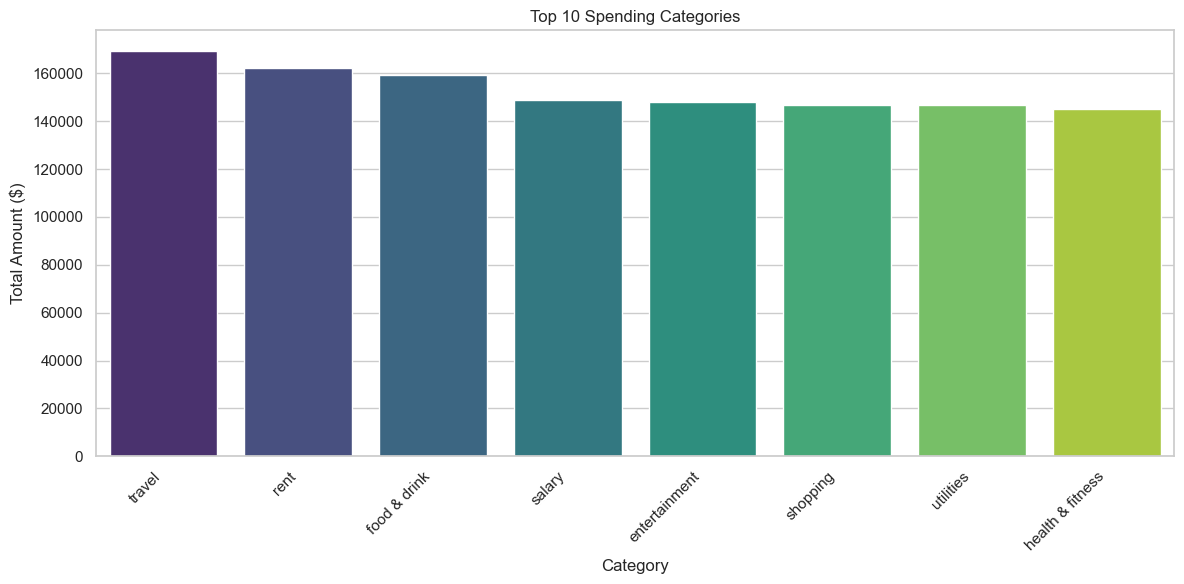

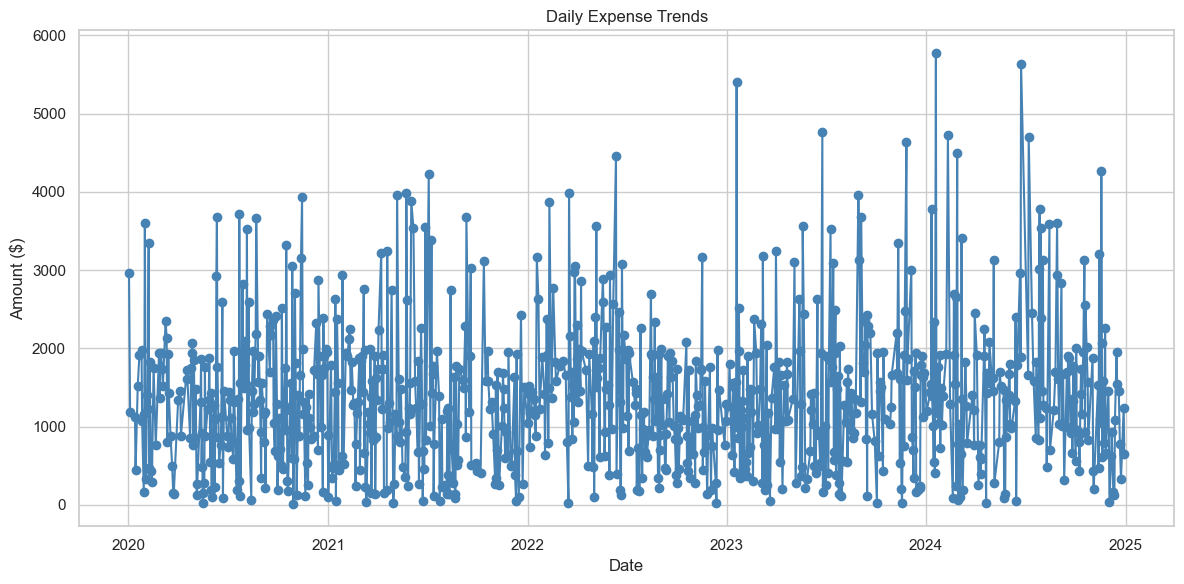

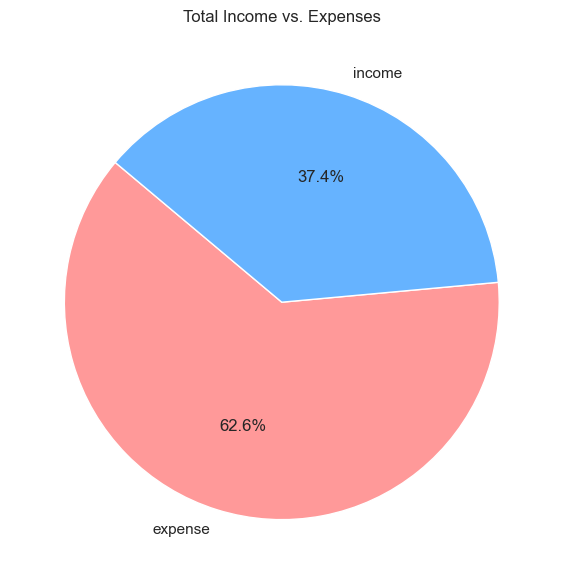

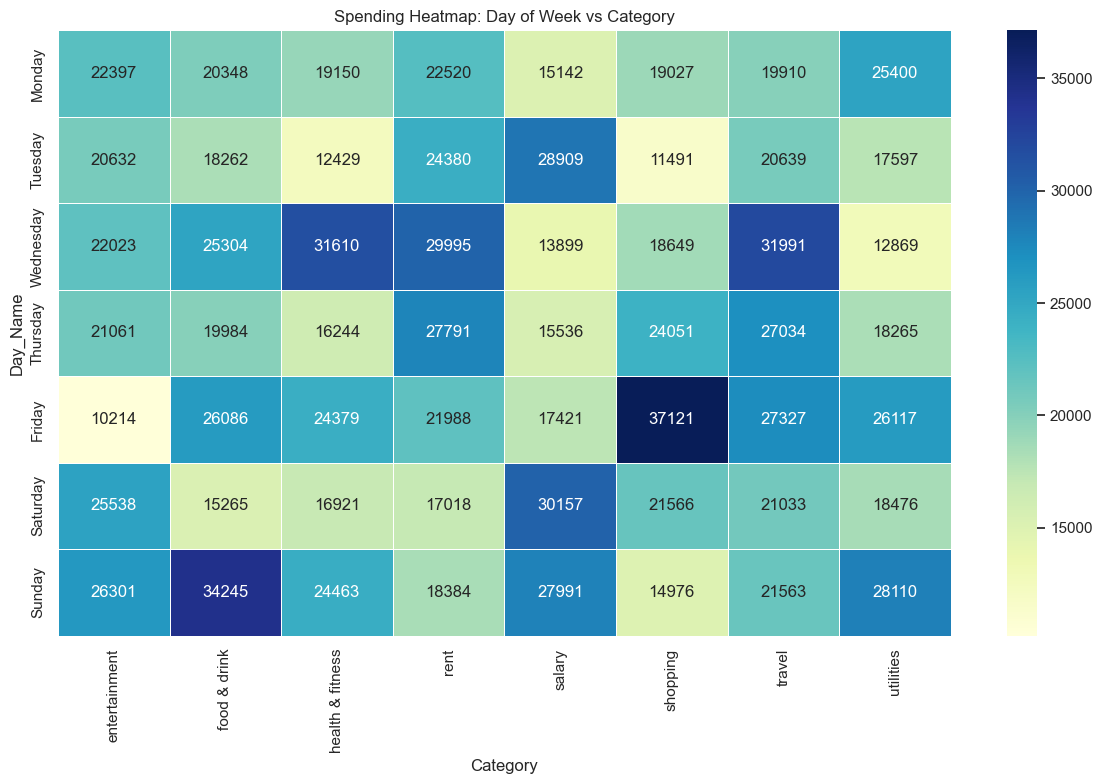

In [35]:
if __name__ == "__main__":
    tracker = FinanceTracker()
    FILENAME = "Personal_Finance_Dataset.csv"

    # 1. Load
    if tracker.load_data(FILENAME):
        # 2. Clean
        tracker.clean_data()
        
        # 3. NumPy Analysis
        tracker.analyze_numpy()
        
        # 4. Pandas Analysis
        tracker.analyze_pandas()
        
        # 5. Visualize
        tracker.visualize_data()